# Phase three: Process

For this project, I'll be cleaning data using Google Sheets and RStudio. I'll be collecting data from the daily activities, daily and hourly steps, daily calories, daily intensities, sleep, and calories burned. I chose to omit the minute-based data since, for the recommendations I'm searching for, the minute-to-minute data is irrelevant.

# Phase four: Google Sheets - Process

After uploading the files mentioned above, my cleaning process included using COUNTUNIQUE to find how many participants were represented across the data, verifying that the dates matched the metadata, and searching for null and outlier values using filters. I standardized the data by changing the dates to MM/DD/YY format, rounding numbers to whole values, and fixing time formatting to be consistent. I removed rows with zero values and unnecessary timestamps. I created pivot tables to easily display relationships within the cleaned data. I validated that the daily minutes did not exceed 1,440 (24 hours), that the data maintained chronological order, and that no values broke real-world rules.

For the first daily activity sheet I analyzed, I looked at the averages of total steps and total distance across light, moderate, very active, and sedentary time — to compare activity levels across user groups and establish a baseline for recommendations — then created a pivot table to clearly display the totaled averages. (P1 = first period of survey collected, P2 = second period of survey collected)

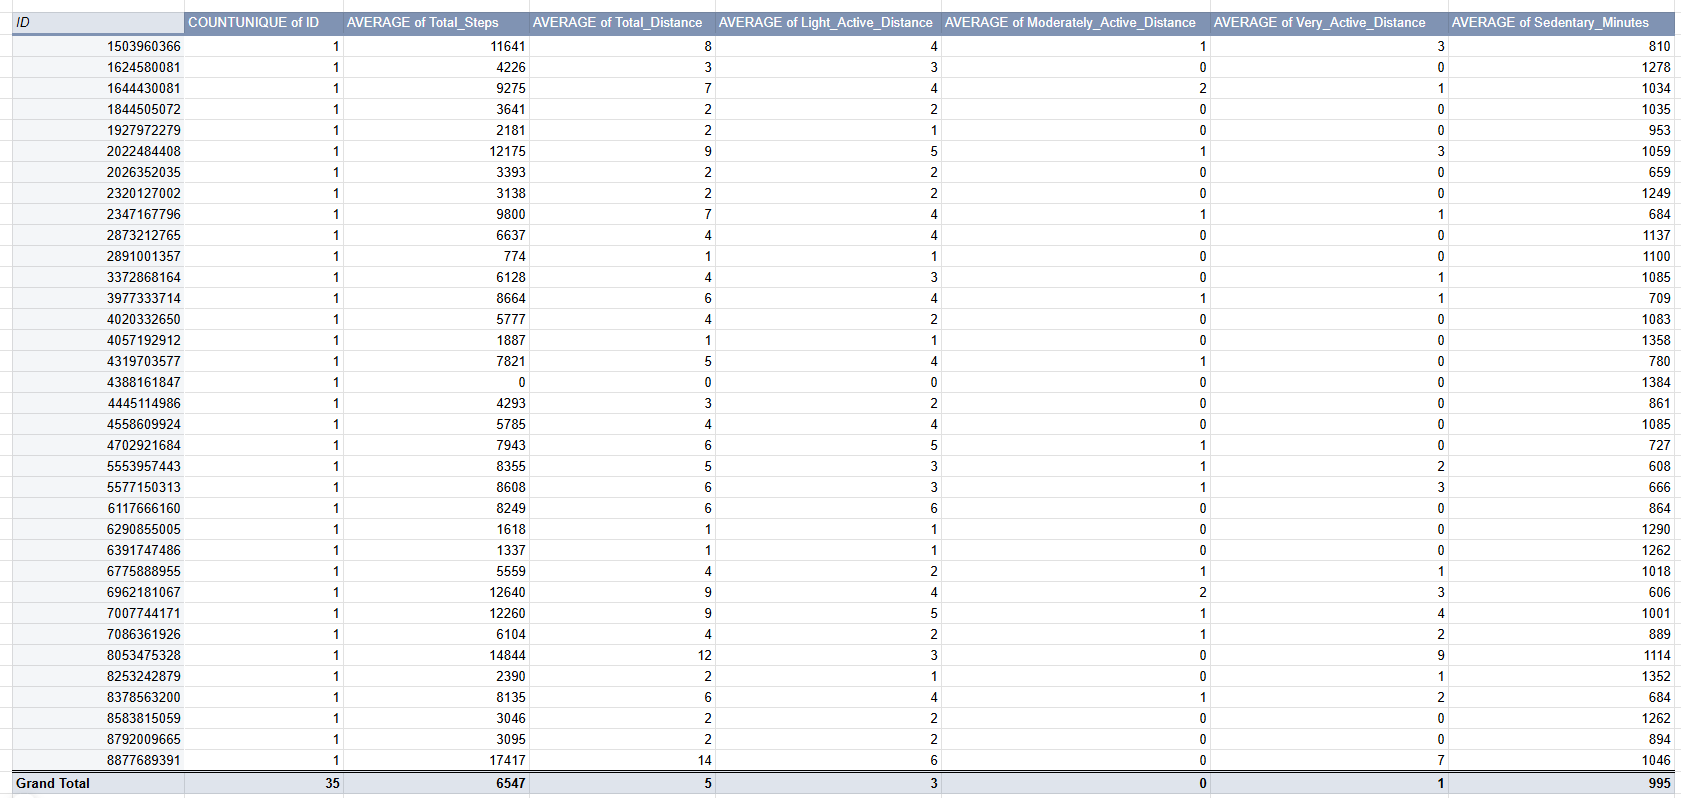

# Phase four: Process R Studio
I'm going to download the following packages to start our R analysis,

* tidyverse
* dblyr
* lubridate
* ggplot2
* janitor
* readr

In [1]:
# Step one load packages
library(tidyverse)
library(dplyr)
library(lubridate)
library(ggplot2)
library(janitor)
library(readr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




Starting with importing the data sets and verifying what lives in each file.

In [2]:
# Verify files
list.files("../input/fitbit/mturkfitbit_export_3.12.16-4.11.16/")
list.files("../input/fitbit/mturkfitbit_export_4.12.16-5.12.16/")

[1] "Fitabase Data 3.12.16-4.11.16"

[1] "Fitabase Data 4.12.16-5.12.16"

These are all of the .CSV files that live in the dataset.

In [3]:
# Verifying more files
list.files("../input/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/")
list.files("../input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/")

[1] "dailyActivity_merged.csv"           "heartrate_seconds_merged.csv"      
 [3] "hourlyCalories_merged.csv"          "hourlyIntensities_merged.csv"      
 [5] "hourlySteps_merged.csv"             "minuteCaloriesNarrow_merged.csv"   
 [7] "minuteIntensitiesNarrow_merged.csv" "minuteMETsNarrow_merged.csv"       
 [9] "minuteSleep_merged.csv"             "minuteStepsNarrow_merged.csv"      
[11] "weightLogInfo_merged.csv"

[1] "dailyActivity_merged.csv"           "dailyCalories_merged.csv"          
 [3] "dailyIntensities_merged.csv"        "dailySteps_merged.csv"             
 [5] "heartrate_seconds_merged.csv"       "hourlyCalories_merged.csv"         
 [7] "hourlyIntensities_merged.csv"       "hourlySteps_merged.csv"            
 [9] "minuteCaloriesNarrow_merged.csv"    "minuteCaloriesWide_merged.csv"     
[11] "minuteIntensitiesNarrow_merged.csv" "minuteIntensitiesWide_merged.csv"  
[13] "minuteMETsNarrow_merged.csv"        "minuteSleep_merged.csv"            
[15] "minuteStepsNarrow_merged.csv"       "minuteStepsWide_merged.csv"        
[17] "sleepDay_merged.csv"                "weightLogInfo_merged.csv"

**Now combining both periods from March to May into one dataset.**

In [4]:
# Combine datasets

# Daily Activity
daily_activity_1 <- read_csv("../input/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/dailyActivity_merged.csv")
daily_activity_2 <- read_csv("../input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")
daily_activity <- bind_rows(daily_activity_1, daily_activity_2)

# Hourly Steps
hourly_steps_1 <- read_csv("../input/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlySteps_merged.csv")
hourly_steps_2 <- read_csv("../input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlySteps_merged.csv")
hourly_steps <- bind_rows(hourly_steps_1, hourly_steps_2)

# Weight Info
weight_info_1 <- read_csv("../input/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/weightLogInfo_merged.csv")
weight_info_2 <- read_csv("../input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/weightLogInfo_merged.csv")
weight_info <- bind_rows(weight_info_1, weight_info_2)

# Sleep Day
sleep_day <- read_csv("../input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")

Rows: 457 Columns: 15


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ActivityDate
dbl (14): Id, TotalSteps, TotalDistance, TrackerDistance, LoggedActivitiesDi...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 940 Columns: 15


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ActivityDate
dbl (14): Id, TotalSteps, TotalDistance, TrackerDistance, LoggedActivitiesDi...


...

── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Date
dbl (6): Id, WeightKg, WeightPounds, Fat, BMI, LogId
lgl (1): IsManualReport



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 413 Columns: 5


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): SleepDay
dbl (4): Id, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


**Now, with datasets combined, clean up column names and standardize dates.**

In [5]:
# Clean column names for all datasets
daily_activity <- daily_activity %>% clean_names()
hourly_steps <- hourly_steps %>% clean_names()
weight_info <- weight_info %>% clean_names()
sleep_day <- sleep_day %>% clean_names()

In [6]:
# Clean dates and times
daily_activity <- daily_activity %>%
  mutate(activity_date = as.Date(activity_date, format = "%m/%d/%Y"))

hourly_steps <- hourly_steps %>%
  mutate(activity_hour = as.POSIXct(activity_hour, format = "%m/%d/%Y %I:%M:%S %p"))

weight_info <- weight_info %>%
  mutate(date = as.POSIXct(date, format = "%m/%d/%Y %I:%M:%S %p"))

sleep_day <- sleep_day %>%
  mutate(sleep_day = as.POSIXct(sleep_day, format = "%m/%d/%Y %I:%M:%S %p"))


**Count unique the amount of users per data frame. Although sleep and weight fall below the sample size of 30, for practice I am keeping them included for practice.**

In [7]:
# Verify amount of people in each period
period1_users <- daily_activity %>%
  filter(activity_date >= as.Date("2016-03-12") & activity_date <= as.Date("2016-04-11")) %>%
  distinct(id) %>%
  nrow()

period2_users <- daily_activity %>%
  filter(activity_date >= as.Date("2016-04-12") & activity_date <= as.Date("2016-05-12")) %>%
  distinct(id) %>%
  nrow()

total_users <- daily_activity %>%
  distinct(id) %>%
  nrow()

cat("========== USERS PER PERIOD ==========\n")
cat("Period 1 (March 12 - April 11):", period1_users, "users\n")
cat("Period 2 (April 12 - May 12):", period2_users, "users\n")
cat("Total unique users:", total_users, "users\n")

========== USERS PER PERIOD ==========


Period 1 (March 12 - April 11): 35 users


Period 2 (April 12 - May 12): 33 users


Total unique users: 35 users


In [8]:
# Verify date range

cat("========== DATE RANGE ==========\n")
cat("First date:", format(min(daily_activity$activity_date), "%B %d, %Y"), "\n")
cat("Last date:", format(max(daily_activity$activity_date), "%B %d, %Y"), "\n")
cat("Total days span:", as.numeric(max(daily_activity$activity_date) - min(daily_activity$activity_date)) + 1, "days\n")
cat("Total weeks:", 9, "weeks\n")

========== DATE RANGE ==========


First date: March 12, 2016 


Last date: May 12, 2016 


Total days span: 62 days


Total weeks: 9 weeks


In [9]:
# Check for duplicates in each dataset
cat("Daily Activity duplicates:", sum(duplicated(daily_activity)), "\n")
cat("Hourly Steps duplicates:", sum(duplicated(hourly_steps)), "\n")
cat("Weight Info duplicates:", sum(duplicated(weight_info)), "\n")
cat("Sleep Day duplicates:", sum(duplicated(sleep_day)), "\n")

Daily Activity duplicates: 0 


Hourly Steps duplicates: 175 


Weight Info duplicates: 2 


Sleep Day duplicates: 3 


Here I found that there were 175 duplicates for hourly steps, which was a concerning outlier that didn't make sense. I can see that there is a gap in the timeline between the end of the first period and the start of the second period, which caused an overlap when the datasets were combined. I will also remove the duplicates found in the weight and sleep data.

In [10]:
# Remove duplicates
hourly_steps <- hourly_steps %>% distinct()
weight_info <- weight_info %>% distinct()
sleep_day <- sleep_day %>% distinct()

cat("Daily Activity duplicates:", sum(duplicated(daily_activity)), "\n")
cat("Hourly Steps duplicates:", sum(duplicated(hourly_steps)), "\n")
cat("Weight Info duplicates:", sum(duplicated(weight_info)), "\n")
cat("Sleep Day duplicates:", sum(duplicated(sleep_day)), "\n")


Daily Activity duplicates: 0 


Hourly Steps duplicates: 0 


Weight Info duplicates: 0 


Sleep Day duplicates: 0 


In [11]:
# Tibble at a glance
daily_activity %>% head(10)
hourly_steps %>% head(10)
weight_info %>% head(10)
sleep_day %>% head(10)

id,activity_date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories
<dbl>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1503960366,2016-03-25,11004,7.11,7.11,0,2.57,0.46,4.07,0,33,12,205,804,1819
1503960366,2016-03-26,17609,11.55,11.55,0,6.92,0.73,3.91,0,89,17,274,588,2154
1503960366,2016-03-27,12736,8.53,8.53,0,4.66,0.16,3.71,0,56,5,268,605,1944
1503960366,2016-03-28,13231,8.93,8.93,0,3.19,0.79,4.95,0,39,20,224,1080,1932
1503960366,2016-03-29,12041,7.85,7.85,0,2.16,1.09,4.61,0,28,28,243,763,1886
1503960366,2016-03-30,10970,7.16,7.16,0,2.36,0.51,4.29,0,30,13,223,1174,1820
1503960366,2016-03-31,12256,7.86,7.86,0,2.29,0.49,5.04,0,33,12,239,820,1889
1503960366,2016-04-01,12262,7.87,7.87,0,3.32,0.83,3.64,0,47,21,200,866,1868
1503960366,2016-04-02,11248,7.25,7.25,0,3.00,0.45,3.74,0,40,11,244,636,1843


id,activity_hour,step_total
<dbl>,<dttm>,<dbl>
1503960366,2016-03-12 00:00:00,0
1503960366,2016-03-12 01:00:00,0
1503960366,2016-03-12 02:00:00,0
1503960366,2016-03-12 03:00:00,0
1503960366,2016-03-12 04:00:00,0
1503960366,2016-03-12 05:00:00,0
1503960366,2016-03-12 06:00:00,0
1503960366,2016-03-12 07:00:00,0
1503960366,2016-03-12 08:00:00,0


id,date,weight_kg,weight_pounds,fat,bmi,is_manual_report,log_id
<dbl>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
1503960366,2016-04-05 23:59:59,53.3,117.5064,22,22.97,TRUE,1.459901e+12
1927972279,2016-04-10 18:33:26,129.6,285.7191,NA,46.17,FALSE,1.460313e+12
2347167796,2016-04-03 23:59:59,63.4,139.7731,10,24.77,TRUE,1.459728e+12
2873212765,2016-04-06 23:59:59,56.7,125.0021,NA,21.45,TRUE,1.459987e+12
2873212765,2016-04-07 23:59:59,57.2,126.1044,NA,21.65,TRUE,1.460074e+12
2891001357,2016-04-05 23:59:59,88.4,194.8886,NA,25.03,TRUE,1.459901e+12
4445114986,2016-03-30 23:59:59,92.4,203.7071,NA,35.01,TRUE,1.459382e+12
4558609924,2016-04-08 23:59:59,69.4,153.0008,NA,27.14,TRUE,1.460160e+12
4702921684,2016-04-04 23:59:59,99.7,219.8009,NA,26.11,TRUE,1.459814e+12


id,sleep_day,total_sleep_records,total_minutes_asleep,total_time_in_bed
<dbl>,<dttm>,<dbl>,<dbl>,<dbl>
1503960366,2016-04-12,1,327,346
1503960366,2016-04-13,2,384,407
1503960366,2016-04-15,1,412,442
1503960366,2016-04-16,2,340,367
1503960366,2016-04-17,1,700,712
1503960366,2016-04-19,1,304,320
1503960366,2016-04-20,1,360,377
1503960366,2016-04-21,1,325,364
1503960366,2016-04-23,1,361,384


# Analyze
We will next analyze the trends of the FitBit users to see if we can draw insights for Bellabeat's marketing team. The questions that will drive our analysis are:

* How many users are consistently active vs. sedentary?

* Is there a relationship between daily activity and sleep quality?

* Why is weight tracking adoption so low (only 13 users)?

* When do users take the most steps throughout the day?

* How can Bellabeat improve user engagement and retention?

**Users activity levels are going to be grouped into categories of sedentary (<5,000 steps), lighly active (5,000 to 7,500 steps), fairly active (7,500 to 10,000 steps), and very active (10,000+ steps). I used this guideline from https://www.brownhealth.org/be-well/do-i-really-need-10000-steps-day to categorize activity levels.**

In [12]:
# Classify users by average daily activity
user_activity_classification <- daily_activity %>%
  group_by(id) %>%
  summarise(
    avg_daily_steps = mean(total_steps),
    total_days = n(),
    days_with_activity = sum(total_steps > 0),
    consistency_rate = (days_with_activity / total_days) * 100
  ) %>%
  mutate(
    activity_category = case_when(
      avg_daily_steps < 5000 ~ "Sedentary",
      avg_daily_steps >= 5000 & avg_daily_steps < 7500 ~ "Lightly Active",
      avg_daily_steps >= 7500 & avg_daily_steps < 10000 ~ "Fairly Active",
      avg_daily_steps >= 10000 ~ "Very Active"
    )
  )

# Count users in each category
user_activity_classification %>%
  count(activity_category) %>%
  mutate(percentage = (n / sum(n)) * 100)

activity_category,n,percentage
<chr>,<int>,<dbl>
Fairly Active,8,22.85714
Lightly Active,7,20.00000
Sedentary,13,37.14286
Very Active,7,20.00000


We see here that 37% are sedentary although, overall 63% are active. The sedentary percentage raises concern.

In [13]:
# Find the relationship between activity and sleep patterns
activity_sleep <- daily_activity %>%
  inner_join(sleep_day, by = c("id" = "id", "activity_date" = "sleep_day")) %>%
  mutate(
    sleep_hours = total_minutes_asleep / 60,
    total_active_minutes = very_active_minutes + fairly_active_minutes + lightly_active_minutes,
    activity_level = case_when(
      total_steps < 5000 ~ "Sedentary",
      total_steps >= 5000 & total_steps < 7500 ~ "Lightly Active",
      total_steps >= 7500 & total_steps < 10000 ~ "Fairly Active",
      total_steps >= 10000 ~ "Very Active"
    )
  )

# Finding correlation
cat("\n========== ACTIVITY & SLEEP CORRELATION ==========\n")
cat("Correlation between steps and sleep hours:", 
    cor(activity_sleep$total_steps, activity_sleep$sleep_hours), "\n")
cat("Correlation between active minutes and sleep hours:", 
    cor(activity_sleep$total_active_minutes, activity_sleep$sleep_hours), "\n\n")

# Average sleep by activity level
cat("Average sleep hours by activity level:\n")
activity_sleep %>%
  group_by(activity_level) %>%
  summarise(
    avg_sleep_hours = round(mean(sleep_hours), 2),
    count = n()
  ) %>%
  arrange(factor(activity_level, levels = c("Sedentary", "Lightly Active", "Fairly Active", "Very Active")))


========== ACTIVITY & SLEEP CORRELATION ==========


Correlation between steps and sleep hours: -0.1932799 


Correlation between active minutes and sleep hours: -0.08016546 



Average sleep hours by activity level:


activity_level,avg_sleep_hours,count
<chr>,<dbl>,<int>
Sedentary,7.57,107
Lightly Active,6.99,73
Fairly Active,7.06,77
Very Active,6.60,165


We are seeing that there is a negative correlation between steps and sleep, and also activity and sleep. Very active people are sleeping less, while sedentary users are sleeping more.

In [14]:
# How often are users logging weight?

total_users <- n_distinct(daily_activity$id)
weight_users <- n_distinct(weight_info$id)

cat("Total users:", total_users, "\n")
cat("Weight tracking users:", weight_users, "\n")
cat("Adoption rate:", round((weight_users / total_users) * 100, 1), "%\n\n")

weight_frequency <- weight_info %>%
  group_by(id) %>%
  summarise(
    total_logs = n(),
    days_between_logs = as.numeric(difftime(max(date), min(date), units = "days")) / total_logs
  )

cat("Average logs per weight tracking user:", mean(weight_frequency$total_logs), "\n")
cat("Average days between weight logs:", mean(weight_frequency$days_between_logs, na.rm = TRUE), "\n")

Total users: 35 


Weight tracking users: 13 


Adoption rate: 37.1 %



Average logs per weight tracking user: 7.538462 


Average days between weight logs: 2.724493 


Only 37% of users track weight, but the users who track are tracking every 2-3 days which shows decent engagment for users who utilize.

In [15]:
# Peak Activity Hours
hourly_activity <- hourly_steps %>%
  mutate(hour = hour(activity_hour)) %>%
  group_by(hour) %>%
  summarise(
    avg_steps = mean(step_total),
    total_steps = sum(step_total)
  ) %>%
  arrange(desc(avg_steps))

cat("Top 5 most active hours:\n")
hourly_activity %>% head(5)


Top 5 most active hours:


hour,avg_steps,total_steps
<int>,<dbl>,<dbl>
19,554.8857,1053728
18,550.2659,1044955
12,534.2591,1024709
14,506.0203,970041
17,499.7121,949453


This pattern could suggest majority of users are on a traditional 9a-5p schedule with activity peaking between lunch (12p-2p) and post work hours (5p-7p)

In [16]:
# Calculate wear rate (days with activity)
engagement_metrics <- daily_activity %>%
  group_by(id) %>%
  summarise(
    total_days = n(),
    zero_step_days = sum(total_steps == 0),
    active_days = sum(total_steps > 0),
    wear_rate = (active_days / total_days) * 100
  )

cat("Average device wear rate:", round(mean(engagement_metrics$wear_rate), 1), "%\n")
cat("Users with >80% wear rate:", sum(engagement_metrics$wear_rate > 80), "\n")
cat("Users with <50% wear rate:", sum(engagement_metrics$wear_rate < 50), "\n\n")

# DEFINE the variables first
total_users <- n_distinct(daily_activity$id)
sleep_users <- n_distinct(sleep_day$id)

# Now use them
cat("Feature adoption breakdown:\n")
cat("Sleep tracking users:", sleep_users, "(", round((sleep_users/total_users)*100, 1), "%)\n")
cat("Activity-only users:", total_users - sleep_users, "\n\n")

# Zero-step day analysis
cat("Zero-step day analysis:\n")
cat("Total zero-step days across all users:", sum(engagement_metrics$zero_step_days), "\n")
cat("Average zero-step days per user:", round(mean(engagement_metrics$zero_step_days), 1), "\n")
cat("Users with zero days of non-wear:", sum(engagement_metrics$zero_step_days == 0), "\n\n")

# Look at consistency over time
cat("Weekly engagement trends:\n")
daily_activity %>%
  mutate(week = week(activity_date)) %>%
  group_by(week) %>%
  summarise(
    avg_steps = mean(total_steps),
    users_active = n_distinct(id)
  ) %>%
  arrange(week) %>%
  print()

Average device wear rate: 87.1 %


Users with >80% wear rate: 24 


Users with <50% wear rate: 2 



Feature adoption breakdown:


Sleep tracking users: 24 ( 68.6 %)


...

Total zero-step days across all users: 138 


Average zero-step days per user: 3.9 


Users with zero days of non-wear: 13 



Weekly engagement trends:


# A tibble: 9 × 3
   week avg_steps users_active
  <dbl>     <dbl>        <int>
1    11     4141.            2
2    12     4040             2
3    13     5497.           11
4    14     7161.           35
5    15     6893.           34
6    16     7852.           33
7    17     7804.           32
8    18     7664.           32
9    19     7093.           29


The average device wear rate of 87.1% is strong. 13 users have perfect wear. 24 users are tracking sleep and 11 are activity-only users. Only two users have poor engagement. Each user roughly tracks 4 days of zero steps, which could suggest these were weekend or rest days. There is a stark drop in active users from week 14 to 19, which could suggest that users lost interest, completed their goal for their tracking period, or simply did not build the habit to keep tracking.
There appears to be an opportunity to convert the 11 activity-only users to utilizing multiple features on the device.